# Modelo aplicado TTAP - Comparación de métodos para paper (Exacto y Heurístico):
#### Eduardo Carrasco Vidal - 22 junio 2026 - Estudiante Doctorado en Ingeniería de Sistemas Complejos

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib
import pulp
import sys
import os
import platform

print("Computational Environment")
print("Python:", sys.version)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PuLP:", pulp.__version__)


Computational Environment
Python: 3.11.3 (main, Apr 19 2023, 18:49:55) [Clang 14.0.6 ]
Platform: macOS-26.5.2-arm64-arm-64bit
NumPy: 1.26.4
Pandas: 3.0.3
SciPy: 1.10.1
Matplotlib: 3.7.1
PuLP: 2.8.0


In [2]:
# Objetivo:
# Comparar una heurística greedy y un modelo exacto sobre la misma instancia TTAP.

import math
import time
from collections import deque, defaultdict
from typing import List
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import coo_matrix

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

### 1. Definición del problema:

In [3]:
# El TTAP consiste en asignar helicópteros heterogéneos a tareas
# distribuidas espacialmente, maximizando el beneficio operacional
# acumulado bajo restricciones de:
#
# - compatibilidad helicóptero-tarea;
# - capacidades de carga, atención médica y traslado de personal;
# - tiempo de vuelo;
# - tiempo de servicio;
# - retorno a base y recuperación;
# - horizonte temporal;
# - ejecución única de cada tarea.
#
# En esta instancia estática:
# todas las tareas están disponibles desde t = 0.
#
# Beneficio temporal:
#
# b_i(t) = S_i(t) / |I|
#
# donde:
#
# S_i(t) = 1, si t <= t_opt_i
# S_i(t) = 0, si t >= t_ineff_i
# S_i(t) = 1 / (1 + exp(alpha * (t - t_eff_i))), en otro caso.
#
# ============================================================

SERVICE_TIME = 6.0
RECOVERY_TIME = 2.0
TMAX = 200.0
ALPHA = 0.1

# Discretización temporal del modelo exacto
TIME_UNIT = 1.0

# Criterio para no seleccionar tareas sin beneficio.
# Si una tarea tiene beneficio 0, no se considera útil para el greedy.
ZERO_BENEFIT_TOL = 0.0

# Umbral para distinguir tareas con beneficio positivo,
# pero operacionalmente muy bajo.
EFFECTIVE_BENEFIT_THRESHOLD = 1e-3

# Escala común para gráficos de beneficio acumulado
BENEFIT_Y_MIN = 0.0
BENEFIT_Y_MAX = 0.70
BENEFIT_Y_STEP = 0.05

# Carpeta para guardar figuras
FIGURES_DIR = "figures_ttap_GPS"
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_current_figure_dual(save_name, dpi=600):
    """
    Guarda la figura actual en formato PNG y PDF.

    Ejemplo:
        save_current_figure_dual("gantt_greedy_ttap")
    """

    base_name, ext = os.path.splitext(save_name)

    if ext.lower() in [".png", ".pdf"]:
        save_name = base_name

    png_path = os.path.join(FIGURES_DIR, f"{save_name}.png")
    pdf_path = os.path.join(FIGURES_DIR, f"{save_name}.pdf")

    plt.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    print(f"Figure saved at: {png_path}")
    print(f"Figure saved at: {pdf_path}")

### 2. Datos del escenario:

In [5]:
# ============================================================
# Configuración del escenario
# ============================================================

N_DEMAND_NODES = 7      # opciones recomendadas: 4 o 7
N_HELICOPTERS = 6       # opciones recomendadas: 4 o 6
N_TASKS = 30            # opciones: 20 o 30

SCENARIO_NAME = f"GPS_{N_DEMAND_NODES}areas_{N_HELICOPTERS}helos_{N_TASKS}tasks"

# Carpeta para guardar figuras del escenario
FIGURES_DIR = os.path.join("figures_ttap_GPS", SCENARIO_NAME)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ============================================================
# Nodos GPS
# ============================================================

GPS_NODES_FULL = {
    "Base": (-36.69111351421891, -73.0478599920742),

    "A": (-36.690249571708435, -73.11382119514015),
    "B": (-36.72874044753118, -73.13967302454246),
    "C": (-36.71966161161023, -73.10794985130552),
    "D": (-36.73592448688629, -73.11327160264372),
    "E": (-36.754608249861455, -73.10756941690252),
    "F": (-36.7757294654864, -73.05936841280295),
    "G": (-36.81499794336835, -73.02359653839595),
}

DEMAND_NODE_ORDER = ["A", "B", "C", "D", "E", "F", "G"]


def build_active_nodes(n_demand_nodes):
    if n_demand_nodes < 1 or n_demand_nodes > len(DEMAND_NODE_ORDER):
        raise ValueError(
            f"n_demand_nodes debe estar entre 1 y {len(DEMAND_NODE_ORDER)}"
        )

    active_names = ["Base"] + DEMAND_NODE_ORDER[:n_demand_nodes]

    active_nodes = {
        name: GPS_NODES_FULL[name]
        for name in active_names
    }

    return active_names, active_nodes


ACTIVE_NODE_NAMES, nodes = build_active_nodes(N_DEMAND_NODES)

# ============================================================
# Tareas base
# ============================================================

BASE_TASK_ROWS = [
    # task_id, visual_required, load, med, pers, t_opt, t_eff, t_ineff
    (1,  True,  200, 2, 1, 20, 40, 60),
    (2,  False, 300, 1, 2, 15, 30, 50),
    (3,  True,  100, 3, 0, 10, 25, 40),
    (4,  False, 200, 0, 3, 30, 50, 70),
    (5,  True,  150, 1, 1, 25, 45, 60),
    (6,  True,  100, 3, 0, 10, 25, 120),
    (7,  False, 400, 0, 3, 30, 50, 90),
    (8,  True,  150, 1, 1, 25, 45, 100),
    (9,  True,  200, 2, 1, 20, 40, 60),
    (10, False, 300, 1, 2, 15, 30, 50),
    (11, True,  100, 3, 0, 10, 25, 40),
    (12, False, 200, 0, 3, 30, 50, 70),
    (13, True,  150, 1, 1, 25, 45, 60),
    (14, True,  100, 3, 0, 10, 25, 120),
    (15, False, 400, 0, 3, 30, 50, 90),
    (16, True,  150, 1, 1, 25, 45, 100),
    (17, True,  150, 1, 1, 25, 45, 60),
    (18, True,  100, 3, 0, 10, 25, 120),
    (19, False, 400, 0, 3, 30, 50, 90),
    (20, True,  150, 1, 1, 25, 45, 100),
]

# Asignación espacial original de las 20 tareas base
BASE_TASK_TO_NODE = {}

for i in [1, 2, 9, 10]:
    BASE_TASK_TO_NODE[i] = "A"

for i in [3, 8, 7, 11, 12, 13, 14]:
    BASE_TASK_TO_NODE[i] = "B"

for i in [5, 6, 15, 16]:
    BASE_TASK_TO_NODE[i] = "C"

for i in [4, 17, 18, 19, 20]:
    BASE_TASK_TO_NODE[i] = "D"


def build_task_rows(n_tasks):
    """
    Construye el conjunto de tareas.
    - Si n_tasks = 20, usa exactamente las 20 tareas base.
    - Si n_tasks = 30, mantiene intactas las 20 tareas base
      y agrega 10 tareas nuevas replicando los perfiles de T1-T10.
    """

    if n_tasks not in [20, 30]:
        raise ValueError("Por ahora N_TASKS debe ser 20 o 30")

    rows = list(BASE_TASK_ROWS)

    if n_tasks == 30:
        additional_profiles = BASE_TASK_ROWS[:10]

        for new_id, base_row in zip(range(21, 31), additional_profiles):
            _, visual, load, med, pers, t_opt, t_eff, t_ineff = base_row

            rows.append(
                (
                    new_id,
                    visual,
                    load,
                    med,
                    pers,
                    t_opt,
                    t_eff,
                    t_ineff,
                )
            )

    return rows


def build_tasks(task_rows):
    return {
        row[0]: {
            "visual": row[1],
            "load": row[2],
            "med": row[3],
            "pers": row[4],
            "t_opt": row[5],
            "t_eff": row[6],
            "t_ineff": row[7],
        }
        for row in task_rows
    }


def build_task_to_node(tasks, active_node_names):
    """
    Mantiene intacta la asignación original de las tareas 1-20.
    Si existen tareas adicionales, se asignan preferentemente
    a los nodos nuevos E, F y G.
    """

    demand_nodes = [
        name for name in active_node_names
        if name != "Base"
    ]

    task_ids = sorted(tasks.keys())
    task_to_node = {}

    # ========================================================
    # 1. Mantener asignación original para tareas 1-20
    # ========================================================

    for task_id in task_ids:
        if task_id in BASE_TASK_TO_NODE:
            node_name = BASE_TASK_TO_NODE[task_id]

            if node_name not in demand_nodes:
                raise ValueError(
                    f"La tarea base {task_id} está asignada a {node_name}, "
                    f"pero ese nodo no está activo."
                )

            task_to_node[task_id] = node_name

    # ========================================================
    # 2. Asignar tareas adicionales, si existen
    # ========================================================

    additional_task_ids = [
        task_id for task_id in task_ids
        if task_id not in BASE_TASK_TO_NODE
    ]

    # Si existen E, F y G activos, las tareas nuevas se asignan ahí.
    new_task_nodes = [
        node_name for node_name in ["E", "F", "G"]
        if node_name in demand_nodes
    ]

    # Si no están activos E-G, se asignan a los nodos de demanda disponibles.
    if len(new_task_nodes) == 0:
        new_task_nodes = demand_nodes

    for idx, task_id in enumerate(additional_task_ids):
        node_name = new_task_nodes[idx % len(new_task_nodes)]
        task_to_node[task_id] = node_name

    # Control de consistencia
    missing_tasks = sorted(set(task_ids) - set(task_to_node.keys()))

    if len(missing_tasks) > 0:
        raise ValueError(
            f"Hay tareas sin nodo asignado: {missing_tasks}"
        )

    return task_to_node


task_rows = build_task_rows(N_TASKS)
tasks = build_tasks(task_rows)
task_to_node = build_task_to_node(tasks, ACTIVE_NODE_NAMES)

# ============================================================
# Helicópteros
# ============================================================

FLEET_ROWS = [
    ("H1", "H125_light",        True,  300, 1, 2, 190),
    ("H2", "H125_light",        False, 300, 1, 2, 190),

    ("H3", "AS365_Dauphin",     True,  500, 2, 4, 210),
    ("H4", "AS365_Dauphin",     False, 500, 2, 4, 210),

    ("H5", "H215M_Cougar",      True,  900, 3, 8, 200),
    ("H6", "H215M_Cougar",      False, 900, 3, 8, 200),
]


def build_helicopters(n_helicopters):
    if n_helicopters < 1 or n_helicopters > len(FLEET_ROWS):
        raise ValueError(
            f"n_helicopters debe estar entre 1 y {len(FLEET_ROWS)}"
        )

    selected_rows = FLEET_ROWS[:n_helicopters]

    return {
        h: {
            "model": model,
            "visual": visual,
            "load": load,
            "med": med,
            "pers": pers,
            "speed": speed,
        }
        for h, model, visual, load, med, pers, speed in selected_rows
    }


helicopters = build_helicopters(N_HELICOPTERS)

# ============================================================
# Control de configuración
# ============================================================

print("=" * 70)
print("SCENARIO CONFIGURATION")
print("=" * 70)

print(f"Scenario name     : {SCENARIO_NAME}")
print(f"Demand nodes      : {N_DEMAND_NODES}")
print(f"Active nodes      : {ACTIVE_NODE_NAMES}")
print(f"Helicopters       : {N_HELICOPTERS}")
print(f"Tasks             : {N_TASKS}")
print(f"Figures directory : {FIGURES_DIR}")

print("\nTasks per node:")
task_distribution = (
    pd.Series(task_to_node)
    .value_counts()
    .sort_index()
)

display(task_distribution.to_frame("Number of tasks"))

print("\nTask-to-node assignment:")
display(
    pd.DataFrame({
        "Task ID": list(task_to_node.keys()),
        "Node": list(task_to_node.values())
    }).sort_values("Task ID")
)

print("\nFleet:")
display(pd.DataFrame(helicopters).T)

SCENARIO CONFIGURATION
Scenario name     : GPS_7areas_6helos_30tasks
Demand nodes      : 7
Active nodes      : ['Base', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Helicopters       : 6
Tasks             : 30
Figures directory : figures_ttap_GPS/GPS_7areas_6helos_30tasks

Tasks per node:


,Number of tasks
A,4
B,7
C,4
D,5
E,4
F,3
G,3



Task-to-node assignment:


,Task ID,Node
0,1,A
1,2,A
2,3,B
3,4,D
4,5,C
5,6,C
6,7,B
7,8,B
8,9,A
9,10,A



Fleet:


,model,visual,load,med,pers,speed
H1,H125_light,True,300,1,2,190
H2,H125_light,False,300,1,2,190
H3,AS365_Dauphin,True,500,2,4,210
H4,AS365_Dauphin,False,500,2,4,210
H5,H215M_Cougar,True,900,3,8,200
H6,H215M_Cougar,False,900,3,8,200


### 3. Funciones comunes:

In [6]:
def haversine_distance_km(node_a, node_b):
    """
    Calcula la distancia geodésica aproximada entre dos nodos GPS
    usando la fórmula de Haversine.

    Las coordenadas deben estar en formato:
    (latitud, longitud)

    Retorna distancia en kilómetros.
    """

    lat1, lon1 = nodes[node_a]
    lat2, lon2 = nodes[node_b]

    radius_earth_km = 6371.0088

    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad

    a = (
        math.sin(delta_lat / 2.0) ** 2
        + math.cos(lat1_rad)
        * math.cos(lat2_rad)
        * math.sin(delta_lon / 2.0) ** 2
    )

    c = 2.0 * math.asin(math.sqrt(a))

    return radius_earth_km * c
    

def travel_time_minutes(h, node_a, node_b):
    if node_a == node_b:
        return 0.0

    distance_km = haversine_distance_km(node_a, node_b)
    speed_kmh = helicopters[h]["speed"]

    return 60.0 * distance_km / speed_kmh


def satisfaction(t, task):
    if t <= task["t_opt"]:
        return 1.0
    if t >= task["t_ineff"]:
        return 0.0
    return 1.0 / (1.0 + math.exp(ALPHA * (t - task["t_eff"])))


def task_benefit(task_id, finish_time):
    return satisfaction(finish_time, tasks[task_id]) / len(tasks)

def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))

def time_from_step(k, time_unit):
    return k * time_unit

def can_execute_task_by_resources(h, task_id, load, med, pers):
    helo = helicopters[h]
    task = tasks[task_id]

    if task["visual"] and not helo["visual"]:
        return False

    if load < task["load"]:
        return False

    if med < task["med"]:
        return False

    if pers < task["pers"]:
        return False

    return True


def helo_to_str(h):
    if isinstance(h, str):
        h = h.strip()
        if h.startswith("H"):
            return h
        return f"H{h}"
    return f"H{int(h)}"


def helo_to_int(h):
    if isinstance(h, str):
        h = h.strip()
        if h.startswith("H"):
            return int(h.replace("H", ""))
        return int(h)
    return int(h)

## Prueba para distancias GPS:

In [7]:
print("GPS nodes activos:")
for node_name, coord in nodes.items():
    print(node_name, coord)

print("\nDistancias desde Base:")
for node_name in nodes:
    if node_name == "Base":
        continue

    d_km = haversine_distance_km("Base", node_name)

    print(
        f"Base → {node_name}: "
        f"{d_km:.3f} km"
    )

GPS nodes activos:
Base (-36.69111351421891, -73.0478599920742)
A (-36.690249571708435, -73.11382119514015)
B (-36.72874044753118, -73.13967302454246)
C (-36.71966161161023, -73.10794985130552)
D (-36.73592448688629, -73.11327160264372)
E (-36.754608249861455, -73.10756941690252)
F (-36.7757294654864, -73.05936841280295)
G (-36.81499794336835, -73.02359653839595)

Distancias desde Base:
Base → A: 5.882 km
Base → B: 9.192 km
Base → C: 6.227 km
Base → D: 7.670 km
Base → E: 8.841 km
Base → F: 9.465 km
Base → G: 13.944 km


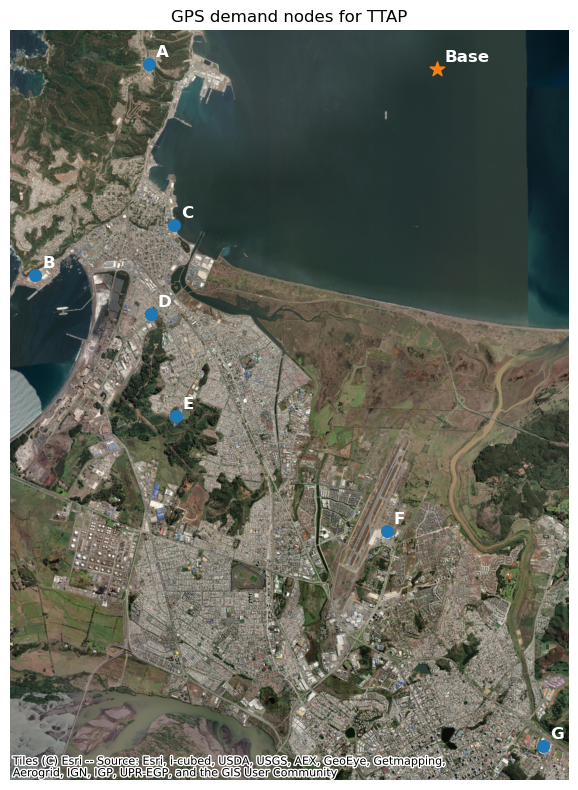

In [8]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import unary_union
import contextily as ctx

GPS_NODES_FULL = {
    "Base": (-36.69111351421891, -73.0478599920742),
    "A": (-36.690249571708435, -73.11382119514015),
    "B": (-36.72874044753118, -73.13967302454246),
    "C": (-36.71966161161023, -73.10794985130552),
    "D": (-36.73592448688629, -73.11327160264372),
    "E": (-36.754608249861455, -73.10756941690252),
    "F": (-36.7757294654864, -73.05936841280295),
    "G": (-36.81499794336835, -73.02359653839595),
}

ACTIVE_NODE_NAMES = ["Base", "A", "B", "C", "D", "E", "F", "G"]

rows = []
for name in ACTIVE_NODE_NAMES:
    lat, lon = GPS_NODES_FULL[name]
    rows.append({
        "name": name,
        "lat": lat,
        "lon": lon,
        "type": "Base" if name == "Base" else "Demand node",
        "geometry": Point(lon, lat),
    })

gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")

# Proyección métrica Web Mercator para poder usar basemap
gdf_3857 = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))

# Dibujar puntos
gdf_3857[gdf_3857["type"] == "Demand node"].plot(
    ax=ax,
    markersize=70
)

gdf_3857[gdf_3857["type"] == "Base"].plot(
    ax=ax,
    markersize=120,
    marker="*"
)

# Etiquetas
for _, row in gdf_3857.iterrows():
    ax.annotate(
        row["name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        color="white",
        fontweight="bold",
        fontsize=12
    )

# Agregar mapa base
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    zoom=16
)

ax.set_title("GPS demand nodes for TTAP", fontsize=12)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("ttap_gps_area_map.pdf", dpi=600, bbox_inches="tight")

plt.show()

### 4. Método Greedy TTAP (Heurística):

In [9]:
class GreedyNode:
    def __init__(self, name, lat, lon):
        self.name = name
        self.lat = lat
        self.lon = lon
        self.tasks = []

    def add_task(self, task):
        self.tasks.append(task)

    def distance_to(self, other):
        """
        Distancia GPS aproximada entre nodos en kilómetros.
        """

        radius_earth_km = 6371.0088

        lat1_rad = math.radians(self.lat)
        lon1_rad = math.radians(self.lon)
        lat2_rad = math.radians(other.lat)
        lon2_rad = math.radians(other.lon)

        delta_lat = lat2_rad - lat1_rad
        delta_lon = lon2_rad - lon1_rad

        a = (
            math.sin(delta_lat / 2.0) ** 2
            + math.cos(lat1_rad)
            * math.cos(lat2_rad)
            * math.sin(delta_lon / 2.0) ** 2
        )

        c = 2.0 * math.asin(math.sqrt(a))

        return radius_earth_km * c


class GreedyTask:
    def __init__(
        self,
        task_id,
        visual_search,
        material_transport,
        medical_assistance,
        personnel_transfer,
        optimal_time,
        effective_time,
        ineffective_time,
    ):
        self.task_id = task_id
        self.visual_search = visual_search
        self.material_transport = material_transport
        self.medical_assistance = medical_assistance
        self.personnel_transfer = personnel_transfer
        self.optimal_time = optimal_time
        self.effective_time = effective_time
        self.ineffective_time = ineffective_time
        self.is_completed = False
        self.completion_time = None

    def calculate_benefit(self, t_finish, n_total):
        if t_finish <= self.optimal_time:
            f = 1.0
        elif t_finish >= self.ineffective_time:
            f = 0.0
        else:
            f = 1.0 / (1.0 + np.exp(ALPHA * (t_finish - self.effective_time)))
        return f / n_total


class GreedyHelicopter:
    def __init__(
        self,
        hid,
        visual_search_capability,
        load_capacity,
        medical_capacity,
        passenger_limit,
        speed_kmh,
        position,
    ):
        self.helicopter_id = hid
        self.visual_search_capability = visual_search_capability

        self.initial_load_capacity = load_capacity
        self.initial_medical_capacity = medical_capacity
        self.initial_passenger_limit = passenger_limit

        self.load_capacity = load_capacity
        self.medical_capacity = medical_capacity
        self.passenger_limit = passenger_limit

        self.speed_kmh = speed_kmh
        self.position = position
        self.available_time = 0.0
        self.blocked = False

    def can_complete_task(self, task):
        return (
            (not task.visual_search or self.visual_search_capability)
            and self.load_capacity >= task.material_transport
            and self.medical_capacity >= task.medical_assistance
            and self.passenger_limit >= task.personnel_transfer
        )

    def execute_task(self, task, t_finish, n_total):
        self.load_capacity -= task.material_transport
        self.medical_capacity -= task.medical_assistance
        self.passenger_limit -= task.personnel_transfer

        task.is_completed = True
        task.completion_time = t_finish

        return task.calculate_benefit(t_finish, n_total)

    def return_to_base_and_recover(self, base_node):
        tau = self.position.distance_to(base_node) / self.speed_kmh * 60.0
        duration = tau + RECOVERY_TIME
    
        k_now = int(round(self.available_time / TIME_UNIT))
        k_finish = k_now + ceil_steps(duration, TIME_UNIT)
        
        self.available_time = time_from_step(k_finish, TIME_UNIT)
        self.position = base_node
        
        self.load_capacity = self.initial_load_capacity
        self.medical_capacity = self.initial_medical_capacity
        self.passenger_limit = self.initial_passenger_limit
        
        return tau, RECOVERY_TIME


def initialize_greedy_graph():
    node_map = {
        node_name: GreedyNode(
            node_name,
            coord[0],
            coord[1],
        )
        for node_name, coord in nodes.items()
    }

    base = node_map["Base"]

    greedy_tasks = {}
    for i, t in tasks.items():
        greedy_tasks[i] = GreedyTask(
            task_id=i,
            visual_search=t["visual"],
            material_transport=t["load"],
            medical_assistance=t["med"],
            personnel_transfer=t["pers"],
            optimal_time=t["t_opt"],
            effective_time=t["t_eff"],
            ineffective_time=t["t_ineff"],
        )

    for task_id, node_name in task_to_node.items():
        node_map[node_name].add_task(greedy_tasks[task_id])

    greedy_helos = []
    for h, p in helicopters.items():
        greedy_helos.append(
            GreedyHelicopter(
                hid=helo_to_int(h),
                visual_search_capability=p["visual"],
                load_capacity=p["load"],
                medical_capacity=p["med"],
                passenger_limit=p["pers"],
                speed_kmh=p["speed"],
                position=base,
            )
        )

    return list(node_map.values()), greedy_helos, greedy_tasks


def next_available_helo(helicopters_list):
    active = [h for h in helicopters_list if not h.blocked]
    if not active:
        return None
    return min(active, key=lambda h: h.available_time)


def solve_greedy_ttap(T_max=TMAX, verbose=True):
    t0 = time.time()

    greedy_nodes, greedy_helos, greedy_tasks = initialize_greedy_graph()

    n_total = sum(len(n.tasks) for n in greedy_nodes)
    pending = n_total

    total_benefit = 0.0
    capacity_log = []
    completion_times = []
    individual_benefits = []

    while pending > 0:
        h = next_available_helo(greedy_helos)

        if h is None:
            break

        if h.available_time >= T_max:
            break

        t_now = h.available_time

        best_task = None
        best_node = None
        best_benefit = ZERO_BENEFIT_TOL
        best_tau = 0.0
        best_finish = 0.0

        for node in greedy_nodes:
            for task in node.tasks:
                if task.is_completed:
                    continue

                if not h.can_complete_task(task):
                    continue

                tau = h.position.distance_to(node) / h.speed_kmh * 60.0
                duration = tau + SERVICE_TIME
                k_now = int(round(t_now / TIME_UNIT))
                k_finish = k_now + ceil_steps(duration, TIME_UNIT)
                t_finish = time_from_step(k_finish, TIME_UNIT)

                if t_finish > T_max:
                    continue

                benefit = task.calculate_benefit(t_finish, n_total)

                if benefit <= ZERO_BENEFIT_TOL:
                    continue

                if benefit > best_benefit:
                    best_task = task
                    best_node = node
                    best_benefit = benefit
                    best_tau = tau
                    best_finish = t_finish

        if best_task is not None:
            h.position = best_node
            h.available_time = best_finish

            benefit = h.execute_task(best_task, best_finish, n_total)
            total_benefit += benefit
            pending -= 1

            completion_times.append(best_finish)
            individual_benefits.append(benefit)

            capacity_log.append({
                "Method": "Greedy",
                "Helo ID": h.helicopter_id,
                "Task ID": best_task.task_id,
                "Node": best_node.name,
                "Flight Time": best_tau,
                "Service Time": SERVICE_TIME,
                "Total Task Time": best_tau + SERVICE_TIME,
                "Completion Time": best_finish,
                "Benefit": benefit,
                "Remaining Load": h.load_capacity,
                "Remaining Medical": h.medical_capacity,
                "Remaining Personnel": h.passenger_limit,
                "Status": "Task Executed",
            })

            if verbose:
                print(
                    f"H{h.helicopter_id} → T{best_task.task_id} "
                    f"fin={best_finish:.1f}' ΔB={benefit:.6f}"
                )

        else:
            base_node = greedy_nodes[0]

            if h.position != base_node:
                tau_return, t_recovery = h.return_to_base_and_recover(base_node)

                capacity_log.append({
                    "Method": "Greedy",
                    "Helo ID": h.helicopter_id,
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": tau_return,
                    "Service Time": t_recovery,
                    "Total Task Time": tau_return + t_recovery,
                    "Completion Time": h.available_time,
                    "Benefit": 0.0,
                    "Remaining Load": h.load_capacity,
                    "Remaining Medical": h.medical_capacity,
                    "Remaining Personnel": h.passenger_limit,
                    "Status": "Idle",
                })

                if verbose:
                    print(f"H{h.helicopter_id} → Base to recover")

            else:
                h.blocked = True

    runtime = time.time() - t0

    df_greedy = pd.DataFrame(capacity_log)

    completed_task_ids = sorted(
        df_greedy[df_greedy["Status"] == "Task Executed"]["Task ID"].astype(int).tolist()
    )

    uncompleted_task_ids = sorted(set(tasks.keys()) - set(completed_task_ids))

    summary = {
        "method": "Greedy",
        "benefit": total_benefit,
        "completed_tasks": len(completed_task_ids),
        "uncompleted_tasks": uncompleted_task_ids,
        "runtime_sec": runtime,
        "optimal": False,
        "solver_message": "Heuristic solution",
        "mip_gap": None,
    }

    if verbose:
        print("\n============================================================")
        print("GREEDY RESULTS")
        print("============================================================")
        print(f"Tareas completadas: {summary['completed_tasks']}/{len(tasks)}")
        print(f"Beneficio total   : {summary['benefit']:.6f}")
        print(f"Tareas no completadas: {summary['uncompleted_tasks']}")
        print(f"Runtime           : {summary['runtime_sec']:.6f} sec")

    return df_greedy, summary, completion_times, individual_benefits


df_greedy, greedy_summary, greedy_times, greedy_benefits = solve_greedy_ttap(
    T_max=TMAX,
    verbose=True
)

display(df_greedy)

H1 → T2 fin=8.0' ΔB=0.033333
H2 → T10 fin=8.0' ΔB=0.033333
H3 → T1 fin=8.0' ΔB=0.033333
H4 → T7 fin=9.0' ΔB=0.033333
H5 → T9 fin=8.0' ΔB=0.033333
H6 → T12 fin=9.0' ΔB=0.033333
H1 → Base to recover
H2 → Base to recover
H3 → T4 fin=16.0' ΔB=0.033333
H5 → T8 fin=16.0' ΔB=0.033333
H4 → Base to recover
H6 → T15 fin=16.0' ΔB=0.033333
H1 → T13 fin=21.0' ΔB=0.033333
H2 → T30 fin=21.0' ΔB=0.023698
H4 → T19 fin=23.0' ΔB=0.033333
H3 → Base to recover
H5 → T24 fin=24.0' ΔB=0.033333
H6 → T22 fin=25.0' ΔB=0.020749
H1 → Base to recover
H2 → Base to recover
H3 → T27 fin=30.0' ΔB=0.033333
H4 → Base to recover
H5 → Base to recover
H6 → Base to recover
H1 → T5 fin=34.0' ΔB=0.025009
H5 → T16 fin=37.0' ΔB=0.022999
H3 → Base to recover
H1 → Base to recover
H3 → T17 fin=44.0' ΔB=0.017499
H5 → T20 fin=44.0' ΔB=0.017499
H1 → T25 fin=47.0' ΔB=0.015006
H3 → T28 fin=52.0' ΔB=0.011060
H5 → Base to recover
H1 → Base to recover
H5 → T21 fin=58.0' ΔB=0.004728
H3 → Base to recover
H5 → Base to recover
H5 → T6 fin=71.0

,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status
0,Greedy,1,2,A,1.857527,6.0,7.857527,8.0,0.033333,0,0,0,Task Executed
1,Greedy,2,10,A,1.857527,6.0,7.857527,8.0,0.033333,0,0,0,Task Executed
2,Greedy,3,1,A,1.680620,6.0,7.680620,8.0,0.033333,300,0,3,Task Executed
3,Greedy,4,7,B,2.626235,6.0,8.626235,9.0,0.033333,100,2,1,Task Executed
4,Greedy,5,9,A,1.764651,6.0,7.764651,8.0,0.033333,700,1,7,Task Executed
5,Greedy,6,12,B,2.757547,6.0,8.757547,9.0,0.033333,700,3,5,Task Executed
6,Greedy,1,Idle,Base,1.857527,2.0,3.857527,12.0,0.000000,300,1,2,Idle
7,Greedy,2,Idle,Base,1.857527,2.0,3.857527,12.0,0.000000,300,1,2,Idle
8,Greedy,3,4,D,1.451161,6.0,7.451161,16.0,0.033333,100,0,0,Task Executed
9,Greedy,5,8,B,1.458292,6.0,7.458292,16.0,0.033333,550,0,6,Task Executed


### 5. Método Exacto TTAP (Solver:HIGHS - High-performance Software for Linear Optimization)

In [10]:
def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))


def time_from_step(k, time_unit):
    return k * time_unit


def make_state(node, k, load, med, pers):
    return (node, int(k), int(load), int(med), int(pers))


def start_state(h):
    p = helicopters[h]
    return make_state("Base", 0, p["load"], p["med"], p["pers"])


def sink_state():
    return ("SINK", -1, 0, 0, 0)


def build_state_graph_for_helicopter(h, time_unit=TIME_UNIT):
    tmax_steps = int(round(TMAX / time_unit))

    s0 = start_state(h)
    sink = sink_state()

    states = set([s0])
    queue = deque([s0])
    arcs = []

    while queue:
        current_state = queue.popleft()

        node, k, load, med, pers = current_state
        current_time = time_from_step(k, time_unit)

        # -----------------------------
        # Arcos de tarea
        # -----------------------------
        for task_id in tasks:

            if not can_execute_task_by_resources(h, task_id, load, med, pers):
                continue

            task_node = task_to_node[task_id]

            flight = travel_time_minutes(h, node, task_node)
            duration = flight + SERVICE_TIME
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new > tmax_steps:
                continue

            finish_time = time_from_step(k_new, time_unit)

            task = tasks[task_id]

            new_state = make_state(
                task_node,
                k_new,
                load - task["load"],
                med - task["med"],
                pers - task["pers"],
            )

            benefit = task_benefit(task_id, finish_time)

            # Evita crear arcos de tareas que ya no generan valor operacional.
            if benefit <= ZERO_BENEFIT_TOL:
                continue

            arcs.append({
                "h": h,
                "from": current_state,
                "to": new_state,
                "kind": "task",
                "task": task_id,
                "start_time": current_time,
                "finish_time": finish_time,
                "flight_time": flight,
                "service_time": SERVICE_TIME,
                "benefit": benefit,
            })

            if new_state not in states:
                states.add(new_state)
                queue.append(new_state)

        # -----------------------------
        # Arco de retorno a base
        # -----------------------------
        if node != "Base":
            flight = travel_time_minutes(h, node, "Base")
            duration = flight + RECOVERY_TIME
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new <= tmax_steps:
                p = helicopters[h]

                new_state = make_state(
                    "Base",
                    k_new,
                    p["load"],
                    p["med"],
                    p["pers"],
                )

                arcs.append({
                    "h": h,
                    "from": current_state,
                    "to": new_state,
                    "kind": "return",
                    "task": None,
                    "start_time": current_time,
                    "finish_time": time_from_step(k_new, time_unit),
                    "flight_time": flight,
                    "service_time": RECOVERY_TIME,
                    "benefit": 0.0,
                })

                if new_state not in states:
                    states.add(new_state)
                    queue.append(new_state)

    # -----------------------------
    # Arcos de término
    # -----------------------------
    states.add(sink)

    for s in list(states):
        if s == sink:
            continue

        node, k, load, med, pers = s

        if node != "Base":
            continue

        arcs.append({
            "h": h,
            "from": s,
            "to": sink,
            "kind": "end",
            "task": None,
            "start_time": time_from_step(k, time_unit),
            "finish_time": time_from_step(k, time_unit),
            "flight_time": 0.0,
            "service_time": 0.0,
            "benefit": 0.0,
        })

    return list(states), arcs


def build_full_exact_graph(time_unit=TIME_UNIT):
    states_by_h = {}
    arcs_by_h = {}
    all_arcs = []

    print("\nConstruyendo red de estados exacta...\n")

    for h in helicopters:
        states, arcs = build_state_graph_for_helicopter(h, time_unit)

        states_by_h[h] = states
        arcs_by_h[h] = arcs
        all_arcs.extend(arcs)

        print(f"{h}: {len(states):,} estados | {len(arcs):,} arcos")

    print(f"\nTotal arcos/variables binarias: {len(all_arcs):,}")

    return states_by_h, arcs_by_h, all_arcs


def build_exact_milp_matrices(states_by_h, arcs_by_h, all_arcs):
    n_vars = len(all_arcs)

    c = np.array([-arc["benefit"] for arc in all_arcs], dtype=float)

    lb = np.zeros(n_vars)
    ub = np.ones(n_vars)
    integrality = np.ones(n_vars, dtype=int)

    row_idx = []
    col_idx = []
    vals = []

    rhs_lb = []
    rhs_ub = []

    current_row = 0

    arc_global_index = {}
    offset = 0

    for h in helicopters:
        for local_idx, arc in enumerate(arcs_by_h[h]):
            arc_global_index[(h, local_idx)] = offset + local_idx
        offset += len(arcs_by_h[h])

    # -----------------------------
    # Conservación de flujo
    # -----------------------------
    for h in helicopters:
        outgoing = defaultdict(list)
        incoming = defaultdict(list)

        for local_idx, arc in enumerate(arcs_by_h[h]):
            j = arc_global_index[(h, local_idx)]
            outgoing[arc["from"]].append(j)
            incoming[arc["to"]].append(j)

        s0 = start_state(h)
        sink = sink_state()

        for state in states_by_h[h]:
            for j in outgoing.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

            for j in incoming.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(-1.0)

            if state == s0:
                rhs = 1.0
            elif state == sink:
                rhs = -1.0
            else:
                rhs = 0.0

            rhs_lb.append(rhs)
            rhs_ub.append(rhs)
            current_row += 1

    # -----------------------------
    # Cada tarea máximo una vez
    # -----------------------------
    for task_id in tasks:
        for j, arc in enumerate(all_arcs):
            if arc["kind"] == "task" and arc["task"] == task_id:
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

        rhs_lb.append(-np.inf)
        rhs_ub.append(1.0)
        current_row += 1

    A = coo_matrix(
        (vals, (row_idx, col_idx)),
        shape=(current_row, n_vars)
    ).tocsr()

    constraints = LinearConstraint(
        A,
        np.array(rhs_lb, dtype=float),
        np.array(rhs_ub, dtype=float)
    )

    bounds = Bounds(lb, ub)

    return c, integrality, bounds, constraints, A


def solve_exact_ttap_v01(time_unit=TIME_UNIT, time_limit=180, mip_rel_gap=1e-6, verbose=True):
    t0 = time.time()

    states_by_h, arcs_by_h, all_arcs = build_full_exact_graph(time_unit)

    c, integrality, bounds, constraints, A = build_exact_milp_matrices(
        states_by_h,
        arcs_by_h,
        all_arcs
    )

    print("\nResolviendo MILP exacto...\n")
    print(f"Variables binarias : {len(all_arcs):,}")
    print(f"Restricciones      : {A.shape[0]:,}")
    print(f"No ceros matriz A  : {A.nnz:,}")
    print(f"Time limit         : {time_limit} segundos")
    print(f"MIP relative gap   : {mip_rel_gap}")

    result = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={
            "time_limit": time_limit,
            "mip_rel_gap": mip_rel_gap,
            "disp": verbose,
        }
    )

    runtime = time.time() - t0

    if result.x is None:
        raise RuntimeError("El solver no encontró solución factible.")

    objective_value = -result.fun

    if result.success:
        mip_gap = 0.0
    else:
        mip_gap = getattr(result, "mip_gap", None)

    summary = {
        "method": "Exact",
        "benefit": objective_value,
        "completed_tasks": None,
        "uncompleted_tasks": None,
        "runtime_sec": runtime,
        "optimal": bool(result.success),
        "solver_message": result.message,
        "mip_gap": mip_gap,
        "variables": len(all_arcs),
        "constraints": A.shape[0],
        "nonzeros": A.nnz,
    }

    print("\n============================================================")
    print("EXACT RESULTS")
    print("============================================================")
    print(f"Solver status      : {result.message}")
    print(f"Beneficio total    : {objective_value:.6f}")
    print(f"Runtime            : {runtime:.6f} sec")
    print(f"Óptimo certificado : {result.success}")

    return result, all_arcs, states_by_h, arcs_by_h, summary


def decode_exact_solution(result, all_arcs):
    selected_indices = [
        j for j, value in enumerate(result.x)
        if value > 0.5
    ]

    selected_arcs = [all_arcs[j] for j in selected_indices]

    selected_by_h = defaultdict(list)

    for arc in selected_arcs:
        selected_by_h[arc["h"]].append(arc)

    rows = []

    for h in helicopters:
        out_arc = {
            arc["from"]: arc
            for arc in selected_by_h[h]
        }

        current = start_state(h)

        while True:
            arc = out_arc.get(current)

            if arc is None:
                break

            if arc["kind"] == "end":
                break

            if arc["kind"] == "task":
                task_id = arc["task"]
                next_state = arc["to"]

                rows.append({
                    "Method": "Exact-HiGHS",
                    "Helo ID": helo_to_int(h),
                    "Task ID": task_id,
                    "Node": task_to_node[task_id],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": arc["benefit"],
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Task Executed",
                })

            elif arc["kind"] == "return":
                next_state = arc["to"]

                rows.append({
                    "Method": "Exact-HiGHS",
                    "Helo ID": helo_to_int(h),
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": 0.0,
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Idle",
                })

            current = arc["to"]

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values(
            by=["Completion Time", "Helo ID"]
        ).reset_index(drop=True)

    return df


result_exact, all_arcs, states_by_h, arcs_by_h, exact_summary = solve_exact_ttap_v01(
    time_unit=TIME_UNIT,
    time_limit=180,
    mip_rel_gap=1e-6,
    verbose=False
)

df_exact = decode_exact_solution(result_exact, all_arcs)

exact_completed = sorted(
    df_exact[df_exact["Status"] == "Task Executed"]["Task ID"].astype(int).tolist()
)

exact_summary["completed_tasks"] = len(exact_completed)
exact_summary["uncompleted_tasks"] = sorted(set(tasks.keys()) - set(exact_completed))

display(df_exact)

print("\nTareas completadas Exact:", exact_summary["completed_tasks"], "/", len(tasks))
print("Tareas no completadas Exact:", exact_summary["uncompleted_tasks"])


Construyendo red de estados exacta...

H1: 190 estados | 397 arcos
H2: 42 estados | 77 arcos
H3: 1,905 estados | 7,360 arcos
H4: 213 estados | 400 arcos
H5: 11,185 estados | 79,197 arcos
H6: 2,087 estados | 8,729 arcos

Total arcos/variables binarias: 96,160

Resolviendo MILP exacto...

Variables binarias : 96,160
Restricciones      : 15,652
No ceros matriz A  : 272,864
Time limit         : 180 segundos
MIP relative gap   : 1e-06

EXACT RESULTS
Solver status      : Optimization terminated successfully. (HiGHS Status 7: Optimal)
Beneficio total    : 0.669187
Runtime            : 49.899688 sec
Óptimo certificado : True


,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status
0,Exact-HiGHS,1,5,C,1.966348,6.0,7.966348,8.0,0.033333,150,0,1,Task Executed
1,Exact-HiGHS,2,10,A,1.857527,6.0,7.857527,8.0,0.033333,0,0,0,Task Executed
2,Exact-HiGHS,3,9,A,1.680620,6.0,7.680620,8.0,0.033333,300,0,3,Task Executed
3,Exact-HiGHS,4,2,A,1.680620,6.0,7.680620,8.0,0.033333,200,1,2,Task Executed
4,Exact-HiGHS,5,6,C,1.868031,6.0,7.868031,8.0,0.033333,800,0,8,Task Executed
5,Exact-HiGHS,6,27,E,2.652390,6.0,8.652390,9.0,0.033333,500,3,5,Task Executed
6,Exact-HiGHS,1,Idle,Base,1.966348,2.0,3.966348,12.0,0.000000,300,1,2,Idle
7,Exact-HiGHS,2,Idle,Base,1.857527,2.0,3.857527,12.0,0.000000,300,1,2,Idle
8,Exact-HiGHS,3,Idle,Base,1.680620,2.0,3.680620,12.0,0.000000,500,2,4,Idle
9,Exact-HiGHS,4,Idle,Base,1.680620,2.0,3.680620,12.0,0.000000,500,2,4,Idle



Tareas completadas Exact: 27 / 30
Tareas no completadas Exact: [3, 11, 23]


#### 5.1. Detalle de States y Arcs:

In [11]:
def states_to_dataframe(states_by_h, time_unit=TIME_UNIT):
    rows = []

    for h, states in states_by_h.items():
        for state in states:
            node, k, load, med, pers = state

            if node == "SINK":
                continue

            rows.append({
                "Helo": h,
                "Node": node,
                "Time Step": k,
                "Time": k * time_unit,
                "Remaining Load": load,
                "Remaining Medical": med,
                "Remaining Personnel": pers,
                "State": state,
            })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["Helo", "Time Step", "Node", "Remaining Load", "Remaining Medical", "Remaining Personnel"]
        )
        .reset_index(drop=True)
    )

In [12]:
def arcs_to_dataframe(arcs_by_h):
    rows = []

    for h, arcs in arcs_by_h.items():
        for arc_id, arc in enumerate(arcs):
            rows.append({
                "Helo": h,
                "Arc ID": arc_id,
                "Kind": arc["kind"],
                "Task": arc["task"],
                "From State": arc["from"],
                "To State": arc["to"],
                "Start Time": arc["start_time"],
                "Finish Time": arc["finish_time"],
                "Flight Time": arc["flight_time"],
                "Service Time": arc["service_time"],
                "Benefit": arc["benefit"],
            })

    return (
        pd.DataFrame(rows)
        .sort_values(["Helo", "Start Time", "Finish Time", "Kind", "Arc ID"])
        .reset_index(drop=True)
    )

##### States:

In [13]:
df_states_exact = states_to_dataframe(states_by_h)
display(df_states_exact[df_states_exact["Helo"] == "H6"].head(10))

,Helo,Node,Time Step,Time,Remaining Load,Remaining Medical,Remaining Personnel,State
13530,H6,Base,0,0.0,900,3,8,"(Base, 0, 900, 3, 8)"
13531,H6,A,8,8.0,600,2,6,"(A, 8, 600, 2, 6)"
13532,H6,C,8,8.0,500,3,5,"(C, 8, 500, 3, 5)"
13533,H6,B,9,9.0,500,3,5,"(B, 9, 500, 3, 5)"
13534,H6,B,9,9.0,700,3,5,"(B, 9, 700, 3, 5)"
13535,H6,D,9,9.0,500,3,5,"(D, 9, 500, 3, 5)"
13536,H6,D,9,9.0,700,3,5,"(D, 9, 700, 3, 5)"
13537,H6,E,9,9.0,500,3,5,"(E, 9, 500, 3, 5)"
13538,H6,E,9,9.0,600,2,6,"(E, 9, 600, 2, 6)"
13539,H6,E,9,9.0,700,3,5,"(E, 9, 700, 3, 5)"


In [14]:
len(df_states_exact[df_states_exact["Helo"] == "H2"])

41

##### Arcs:

In [15]:
df_arcs_exact = arcs_to_dataframe(arcs_by_h)
display(df_arcs_exact[df_arcs_exact["Helo"] == "H5"].head(5))

,Helo,Arc ID,Kind,Task,From State,To State,Start Time,Finish Time,Flight Time,Service Time,Benefit
8234,H5,79194,end,NaN,"(Base, 0, 900, 3, 8)","(SINK, -1, 0, 0, 0)",0.0,0.0,0.000000,0.0,0.000000
8235,H5,0,task,1.0,"(Base, 0, 900, 3, 8)","(A, 8, 700, 1, 7)",0.0,8.0,1.764651,6.0,0.033333
8236,H5,1,task,2.0,"(Base, 0, 900, 3, 8)","(A, 8, 600, 2, 6)",0.0,8.0,1.764651,6.0,0.033333
8237,H5,4,task,5.0,"(Base, 0, 900, 3, 8)","(C, 8, 750, 2, 7)",0.0,8.0,1.868031,6.0,0.033333
8238,H5,5,task,6.0,"(Base, 0, 900, 3, 8)","(C, 8, 800, 0, 8)",0.0,8.0,1.868031,6.0,0.033333


### 6. Resumen comparativo básico:

In [16]:
basic_comparison = pd.DataFrame([
    {
        "Method": "Greedy",
        "Accumulated Benefit": greedy_summary["benefit"],
        "Completed Tasks": greedy_summary["completed_tasks"],
        "Completion Rate": greedy_summary["completed_tasks"] / len(tasks),
        "Uncompleted Tasks": greedy_summary["uncompleted_tasks"],
        "Runtime sec": greedy_summary["runtime_sec"],
        "Optimal Certified": greedy_summary["optimal"],
        "MIP Gap": greedy_summary["mip_gap"],
    },
    {
        "Method": "Exact-HiGHS",
        "Accumulated Benefit": exact_summary["benefit"],
        "Completed Tasks": exact_summary["completed_tasks"],
        "Completion Rate": exact_summary["completed_tasks"] / len(tasks),
        "Uncompleted Tasks": exact_summary["uncompleted_tasks"],
        "Runtime sec": exact_summary["runtime_sec"],
        "Optimal Certified": exact_summary["optimal"],
        "MIP Gap": exact_summary["mip_gap"],
    }
])

display(basic_comparison)

benefit_gain = exact_summary["benefit"] - greedy_summary["benefit"]
relative_gap_greedy_to_exact = benefit_gain / exact_summary["benefit"]

print("============================================================")
print("COMPARACIÓN DE CALIDAD")
print("============================================================")
print(f"Beneficio Greedy      : {greedy_summary['benefit']:.6f}")
print(f"Beneficio Exact       : {exact_summary['benefit']:.6f}")
print(f"Mejora absoluta       : {benefit_gain:.6f}")
print(f"Brecha relativa Greedy respecto del exacto: {100 * relative_gap_greedy_to_exact:.2f}%")

,Method,Accumulated Benefit,Completed Tasks,Completion Rate,Uncompleted Tasks,Runtime sec,Optimal Certified,MIP Gap
0,Greedy,0.592031,26,0.866667,"[3, 11, 23, 29]",0.001455,False,NaN
1,Exact-HiGHS,0.669187,27,0.900000,"[3, 11, 23]",49.899688,True,0.0


COMPARACIÓN DE CALIDAD
Beneficio Greedy      : 0.592031
Beneficio Exact       : 0.669187
Mejora absoluta       : 0.077156
Brecha relativa Greedy respecto del exacto: 11.53%


### 7. Gantt Chart:

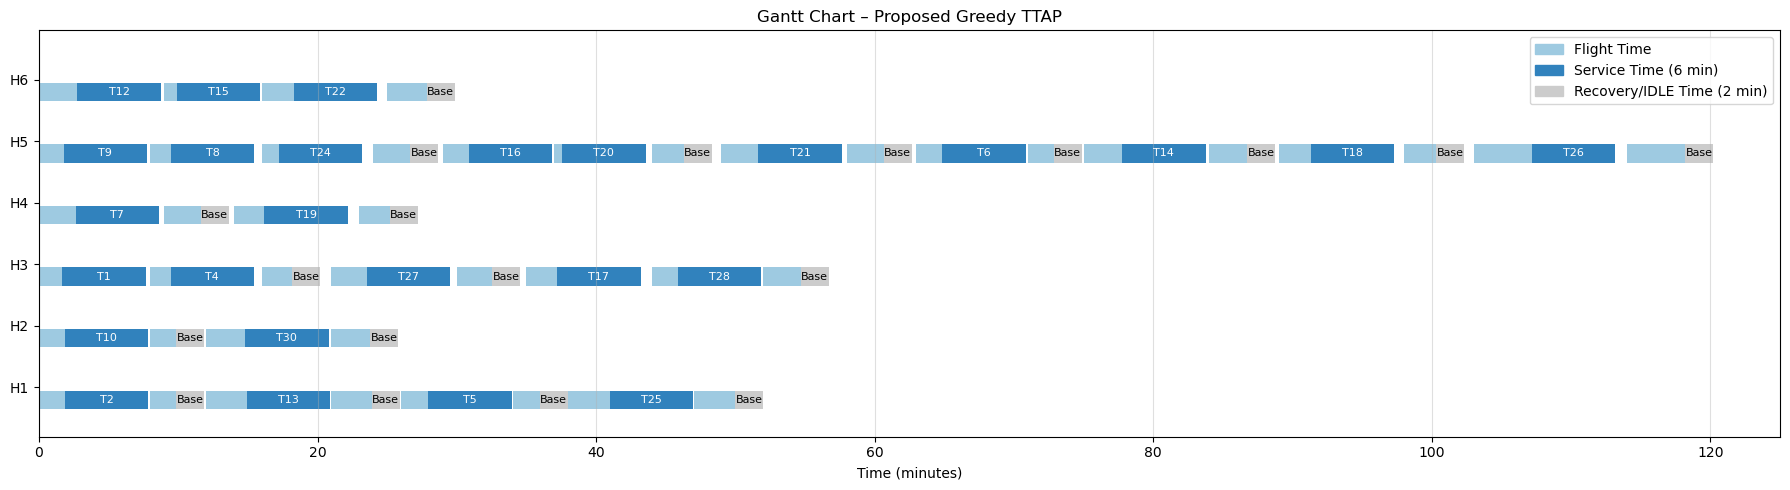

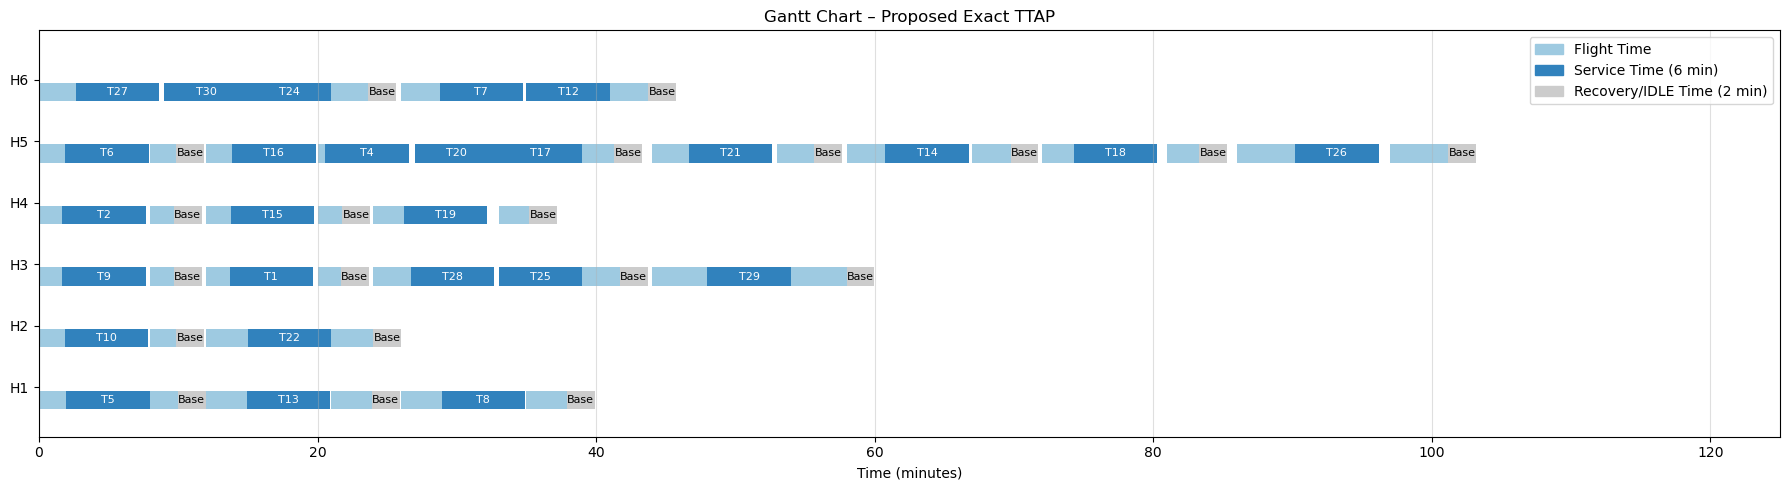

In [20]:
def plot_ttap_gantt_like_greedy(
    df_capacity,
    title="Gantt Chart – TTAP",
    fixed_service_time=6,
    show_benefit=False,
    xlim=(0, 160),
    save_path=None
):
    records = []
    prev_finish = {}

    df_plot = df_capacity.copy()
    df_plot["Helo ID"] = df_plot["Helo ID"].apply(helo_to_int)
    df_plot = df_plot.sort_values(by=["Completion Time", "Helo ID"]).reset_index(drop=True)

    for _, row in df_plot.iterrows():
        heli = int(row["Helo ID"])
        task = row["Task ID"]
        finish = float(row["Completion Time"])
        service_time = float(row["Service Time"])
        flight_time = float(row["Flight Time"])
        status = row["Status"]

        start = prev_finish.get(heli, 0.0)
        travel = flight_time
        actual_service = service_time
        prev_finish[heli] = finish

        benefit = None
        if "Benefit" in df_plot.columns and pd.notna(row["Benefit"]):
            benefit = float(row["Benefit"])

        records.append({
            "heli": heli,
            "task": task,
            "start": start,
            "travel": travel,
            "service": actual_service,
            "status": status,
            "benefit": benefit,
        })

    if not records:
        print("No hay datos para graficar.")
        return

    fig, ax = plt.subplots(figsize=(18, 5))

    colors = dict(
        travel="#9ecae1",
        service="#3182bd",
        idle="#cccccc"
    )

    for rec in records:
        y = rec["heli"]

        if rec["travel"] > 0:
            ax.broken_barh(
                [(rec["start"], rec["travel"])],
                (y - 0.35, 0.3),
                facecolors=colors["travel"]
            )

        service_start = rec["start"] + rec["travel"]

        ax.broken_barh(
            [(service_start, rec["service"])],
            (y - 0.35, 0.3),
            facecolors=colors["service"] if rec["status"] == "Task Executed" else colors["idle"]
        )

        if rec["status"] == "Task Executed":
            if show_benefit and rec["benefit"] is not None:
                label = f"T{rec['task']}\n{rec['benefit']:.3f}"
            else:
                label = f"T{rec['task']}"

            ax.text(
                service_start + rec["service"] / 2,
                y - 0.35 + 0.15,
                label,
                ha="center",
                va="center",
                color="white",
                fontsize=8
            )
        else:
            ax.text(
                service_start + rec["service"] / 2,
                y - 0.35 + 0.15,
                "Base",
                ha="center",
                va="center",
                color="black",
                fontsize=8
            )

    helos = sorted(set(r["heli"] for r in records))

    ax.set_xlabel("Time (minutes)")
    ax.set_yticks(helos)
    ax.set_yticklabels([f"H{i}" for i in helos])
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.4)
    ax.set_ylim(0.2, max(helos) + 0.8)

    if xlim is not None:
        ax.set_xlim(xlim)

    patches = [
        mpatches.Patch(color=colors["travel"], label="Flight Time"),
        mpatches.Patch(color=colors["service"], label=f"Service Time ({fixed_service_time} min)"),
        mpatches.Patch(color=colors["idle"], label="Recovery/IDLE Time (2 min)")
    ]

    ax.legend(handles=patches, loc="upper right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_ttap_gantt_like_greedy(
    df_greedy,
    title="Gantt Chart – Proposed Greedy TTAP",
    show_benefit=False,
    xlim=(0, 125),
    save_path=os.path.join(FIGURES_DIR, "gantt_greedy_ttap.pdf")
)

plot_ttap_gantt_like_greedy(
    df_exact,
    title="Gantt Chart – Proposed Exact TTAP",
    show_benefit=False,
    xlim=(0, 125),
    save_path=os.path.join(FIGURES_DIR, "gantt_exact_ttap.pdf")
)

### 8. Beneficio acumulado:

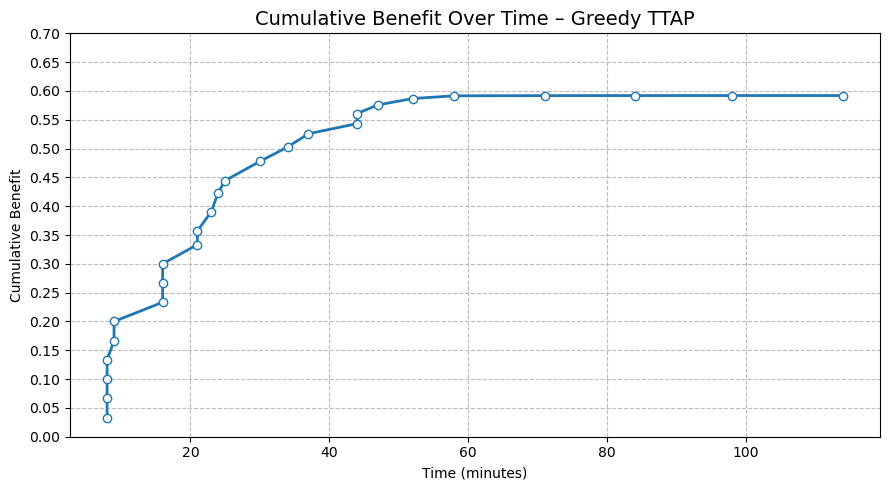

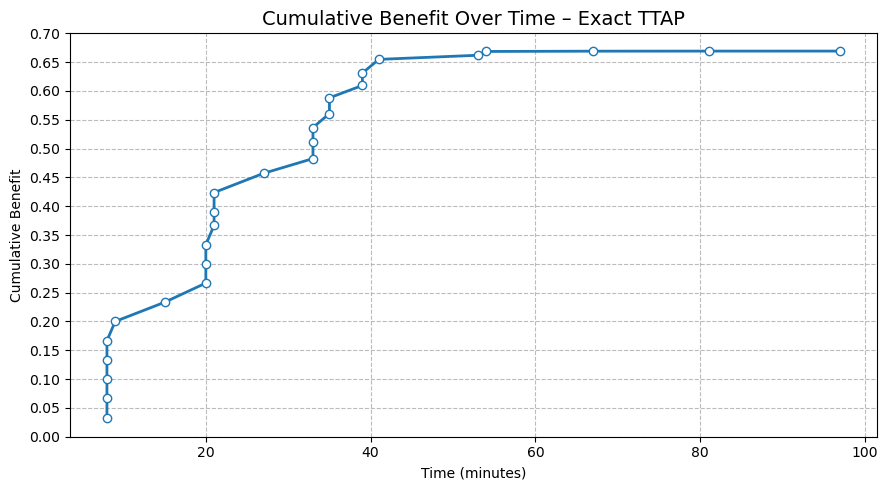

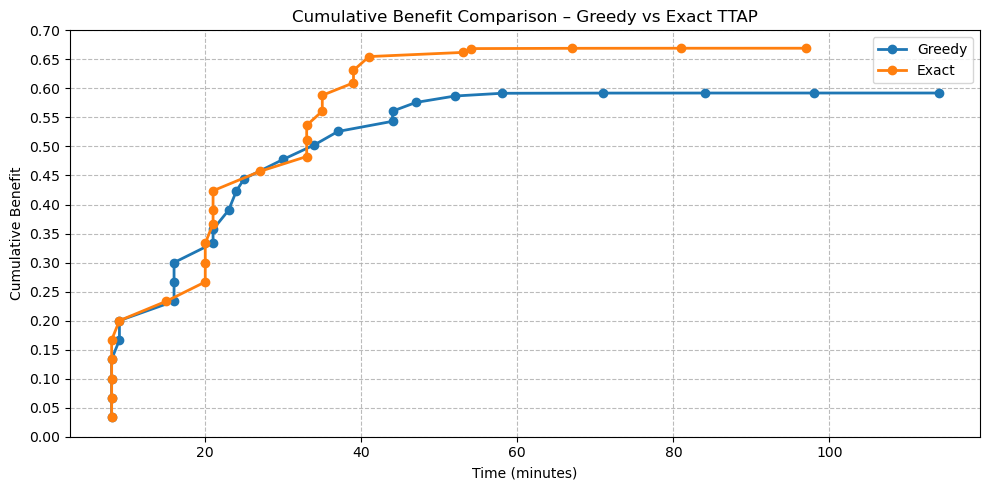

In [21]:
def plot_cumulative_benefit(df, title="Cumulative Benefit Over Time", save_path=None):
    task_df = df[df["Status"] == "Task Executed"].copy()

    if task_df.empty:
        print("No hay tareas ejecutadas.")
        return

    task_df = task_df.sort_values("Completion Time")
    task_df["Cumulative Benefit"] = task_df["Benefit"].cumsum()

    plt.figure(figsize=(9, 5))
    plt.plot(
        task_df["Completion Time"],
        task_df["Cumulative Benefit"],
        marker="o",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="#1f77b4",
        color="#1f77b4",
        linewidth=2
    )

    plt.xlabel("Time (minutes)")
    plt.ylabel("Cumulative Benefit")
    plt.title(title, fontsize=14)

    plt.ylim(BENEFIT_Y_MIN, 0.7)
    plt.yticks(
        np.arange(
            BENEFIT_Y_MIN,
            BENEFIT_Y_MAX + BENEFIT_Y_STEP,
            BENEFIT_Y_STEP
        )
    )
    
    plt.grid(True, axis="both", which="major", linestyle="--", linewidth=0.8, alpha=0.85)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_cumulative_benefit_comparison(df_greedy, df_exact, save_path=None):
    def prepare(df, method):
        task_df = df[df["Status"] == "Task Executed"].copy()
        task_df = task_df.sort_values("Completion Time")
        task_df["Cumulative Benefit"] = task_df["Benefit"].cumsum()
        task_df["Method"] = method
        return task_df

    g = prepare(df_greedy, "Greedy")
    e = prepare(df_exact, "Exact")

    plt.figure(figsize=(10, 5))

    plt.plot(
        g["Completion Time"],
        g["Cumulative Benefit"],
        marker="o",
        linewidth=2,
        label="Greedy"
    )

    plt.plot(
        e["Completion Time"],
        e["Cumulative Benefit"],
        marker="o",
        linewidth=2,
        label="Exact"
    )

    plt.xlabel("Time (minutes)")
    plt.ylabel("Cumulative Benefit")
    plt.title("Cumulative Benefit Comparison – Greedy vs Exact TTAP")

    plt.ylim(BENEFIT_Y_MIN, 0.7)
    plt.yticks(
        np.arange(
            BENEFIT_Y_MIN,
            BENEFIT_Y_MAX + BENEFIT_Y_STEP,
            BENEFIT_Y_STEP
        )
    )   
    
    plt.grid(True, axis="both", which="major", linestyle="--", linewidth=0.8, alpha=0.85)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()


plot_cumulative_benefit(
    df_greedy,
    title="Cumulative Benefit Over Time – Greedy TTAP",
    save_path=os.path.join(FIGURES_DIR, "cumulative_benefit_greedy_ttap.pdf")
)

plot_cumulative_benefit(
    df_exact,
    title="Cumulative Benefit Over Time – Exact TTAP",
    save_path=os.path.join(FIGURES_DIR, "cumulative_benefit_exact_ttap.pdf")
)

plot_cumulative_benefit_comparison(
    df_greedy,
    df_exact,
    save_path=os.path.join(FIGURES_DIR, "cumulative_benefit_comparison_greedy_vs_exact.pdf")
)

### 9. Métricas comparativas:

In [22]:
def gini_coefficient(values):
    values = np.array(values, dtype=float)

    if len(values) == 0:
        return np.nan

    if np.all(values == 0):
        return 0.0

    values = np.sort(values)
    n = len(values)
    cumulative = np.cumsum(values)

    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n


def compute_ttap_metrics(df, method_name, runtime_sec=None, optimal=False, mip_gap=None, exact_benefit_reference=None):
    df = df.copy()

    df["Helo ID"] = df["Helo ID"].apply(helo_to_int)

    task_df = df[df["Status"] == "Task Executed"].copy()
    idle_df = df[df["Status"] != "Task Executed"].copy()

    total_tasks = len(tasks)
    
    accumulated_benefit = task_df["Benefit"].sum() if not task_df.empty else 0.0
    
    # Tareas físicamente ejecutadas,
    # aunque hayan llegado tarde y tengan beneficio cero.
    physical_completed_tasks = task_df["Task ID"].nunique()
    
    # Tareas con beneficio estrictamente positivo.
    positive_task_df = task_df[task_df["Benefit"] > ZERO_BENEFIT_TOL].copy()
    positive_completed_tasks = positive_task_df["Task ID"].nunique()
    
    # Tareas operacionalmente relevantes.
    # Esto elimina tareas con beneficio positivo, pero casi nulo.
    relevant_task_df = task_df[task_df["Benefit"] > EFFECTIVE_BENEFIT_THRESHOLD].copy()
    relevant_completed_tasks = relevant_task_df["Task ID"].nunique()
    
    physical_completion_rate = physical_completed_tasks / total_tasks
    positive_completion_rate = positive_completed_tasks / total_tasks
    relevant_completion_rate = relevant_completed_tasks / total_tasks

    # En escenario estático, todas las tareas están disponibles desde t=0.
    # Por tanto, response time = completion time.
    avg_response_time = task_df["Completion Time"].mean() if not task_df.empty else np.nan
    max_response_time = task_df["Completion Time"].max() if not task_df.empty else np.nan

    avg_activity_duration = task_df["Total Task Time"].mean() if not task_df.empty else np.nan
    max_activity_duration = task_df["Total Task Time"].max() if not task_df.empty else np.nan

    makespan = df["Completion Time"].max() if not df.empty else 0.0

    total_task_flight_time = task_df["Flight Time"].sum() if not task_df.empty else 0.0
    total_return_flight_time = idle_df["Flight Time"].sum() if not idle_df.empty else 0.0
    total_flight_time = total_task_flight_time + total_return_flight_time

    total_task_service_time = task_df["Service Time"].sum() if not task_df.empty else 0.0
    total_recovery_time = idle_df["Service Time"].sum() if not idle_df.empty else 0.0

    # Utilización de recursos:
    # - productive utilization: vuelo a tarea + servicio de tarea
    # - active utilization: vuelo total + servicio de tarea
    #   recuperación se considera no productiva.
    total_available_time = makespan * len(helicopters) if makespan > 0 else np.nan

    productive_time = total_task_flight_time + total_task_service_time
    active_time = total_flight_time + total_task_service_time

    productive_utilization = productive_time / total_available_time if total_available_time else np.nan
    active_utilization = active_time / total_available_time if total_available_time else np.nan

    # Operational cost proxy:
    operational_cost_proxy = total_flight_time + total_recovery_time

    # Load balancing
    tasks_by_helo = task_df.groupby("Helo ID")["Task ID"].count().reindex([1, 2, 3, 4], fill_value=0)
    workload_by_helo = df.groupby("Helo ID")["Total Task Time"].sum().reindex([1, 2, 3, 4], fill_value=0.0)

    task_count_std = tasks_by_helo.std()
    task_count_cv = tasks_by_helo.std() / tasks_by_helo.mean() if tasks_by_helo.mean() > 0 else np.nan
    task_count_gini = gini_coefficient(tasks_by_helo.values)

    workload_std = workload_by_helo.std()
    workload_cv = workload_by_helo.std() / workload_by_helo.mean() if workload_by_helo.mean() > 0 else np.nan
    workload_gini = gini_coefficient(workload_by_helo.values)

    if exact_benefit_reference is not None and exact_benefit_reference > 0:
        optimality_gap_vs_exact = (exact_benefit_reference - accumulated_benefit) / exact_benefit_reference
    else:
        optimality_gap_vs_exact = np.nan

    metrics = {
        "Method": method_name,

        # Solution quality
        "Accumulated Benefit": accumulated_benefit,
        "Optimality Gap vs Exact": optimality_gap_vs_exact,

        # Task completion
        "Physical Completed Tasks": physical_completed_tasks,
        "Physical Completion Rate": physical_completion_rate,
        "Positive Benefit Tasks": positive_completed_tasks,
        "Positive Benefit Completion Rate": positive_completion_rate,
        "Operationally Relevant Tasks": relevant_completed_tasks,
        "Operationally Relevant Completion Rate": relevant_completion_rate,

        # Response time
        "Average Response Time": avg_response_time,
        "Maximum Response Time": max_response_time,
        "Average Activity Duration": avg_activity_duration,
        "Maximum Activity Duration": max_activity_duration,

        # Resource utilization
        "Makespan": makespan,
        "Total Available Fleet Time": total_available_time,
        "Productive Time": productive_time,
        "Active Time": active_time,
        "Productive Utilization": productive_utilization,
        "Active Utilization": active_utilization,

        # Operational cost proxies
        "Total Task Flight Time": total_task_flight_time,
        "Total Return Flight Time": total_return_flight_time,
        "Total Flight Time": total_flight_time,
        "Total Recovery Time": total_recovery_time,
        "Operational Cost Proxy": operational_cost_proxy,

        # Load balancing
        "Task Count Std": task_count_std,
        "Task Count CV": task_count_cv,
        "Task Count Gini": task_count_gini,
        "Workload Std": workload_std,
        "Workload CV": workload_cv,
        "Workload Gini": workload_gini,

        # Computational efficiency
        "Runtime sec": runtime_sec,
        "Optimal Certified": optimal,
        "MIP Gap": mip_gap,
    }

    detail = {
        "tasks_by_helo": tasks_by_helo,
        "workload_by_helo": workload_by_helo,
    }

    return metrics, detail


exact_reference_benefit = exact_summary["benefit"]

greedy_metrics, greedy_metric_detail = compute_ttap_metrics(
    df_greedy,
    method_name="Greedy",
    runtime_sec=greedy_summary["runtime_sec"],
    optimal=False,
    mip_gap=None,
    exact_benefit_reference=exact_reference_benefit
)

exact_metrics, exact_metric_detail = compute_ttap_metrics(
    df_exact,
    method_name="Exact - HiGHS",
    runtime_sec=exact_summary["runtime_sec"],
    optimal=exact_summary["optimal"],
    mip_gap=exact_summary["mip_gap"],
    exact_benefit_reference=exact_reference_benefit
)

df_metrics = pd.DataFrame([greedy_metrics, exact_metrics])

display(df_metrics.T)

,0,1
Method,Greedy,Exact - HiGHS
Accumulated Benefit,0.592031,0.669187
Optimality Gap vs Exact,0.115298,0.0
Physical Completed Tasks,26,27
Physical Completion Rate,0.866667,0.9
Positive Benefit Tasks,26,27
Positive Benefit Completion Rate,0.866667,0.9
Operationally Relevant Tasks,22,24
Operationally Relevant Completion Rate,0.733333,0.8
Average Response Time,35.576923,31.62963


### 10. Tabla de balance por Helo:

In [23]:
def build_helo_balance_table(df, method_name):
    df = df.copy()
    df["Helo ID"] = df["Helo ID"].apply(helo_to_int)

    task_df = df[df["Status"] == "Task Executed"].copy()

    balance = []

    for h in [1, 2, 3, 4, 5, 6]:
        df_h = df[df["Helo ID"] == h]
        task_h = task_df[task_df["Helo ID"] == h]

        balance.append({
            "Method": method_name,
            "Helo ID": f"H{h}",
            "Tasks Executed": task_h["Task ID"].nunique(),
            "Benefit": task_h["Benefit"].sum(),
            "Flight Time": df_h["Flight Time"].sum(),
            "Task Service Time": task_h["Service Time"].sum(),
            "Recovery Time": df_h[df_h["Status"] != "Task Executed"]["Service Time"].sum(),
            "Workload Time": df_h["Total Task Time"].sum(),
            "Last Completion Time": df_h["Completion Time"].max() if not df_h.empty else 0.0,
        })

    return pd.DataFrame(balance)


df_balance_greedy = build_helo_balance_table(df_greedy, "Greedy")
df_balance_exact = build_helo_balance_table(df_exact, "Exact")

df_balance = pd.concat([df_balance_greedy, df_balance_exact], ignore_index=True)

display(df_balance)

,Method,Helo ID,Tasks Executed,Benefit,Flight Time,Task Service Time,Recovery Time,Workload Time,Last Completion Time
0,Greedy,H1,4,0.106681,19.430759,24.0,8.0,51.430759,52.0
1,Greedy,H2,2,0.057032,9.299033,12.0,4.0,25.299033,26.0
2,Greedy,H3,5,0.128560,17.136755,30.0,6.0,53.136755,57.0
3,Greedy,H4,2,0.066667,9.635158,12.0,4.0,25.635158,28.0
4,Greedy,H5,10,0.145677,39.346236,60.0,14.0,113.346236,121.0
5,Greedy,H6,3,0.087415,8.774510,18.0,2.0,28.774510,30.0
6,Exact,H1,3,0.091035,15.543420,18.0,6.0,39.543420,40.0
7,Exact,H2,2,0.057032,9.692701,12.0,4.0,25.692701,26.0
8,Exact,H3,5,0.120400,20.098779,30.0,8.0,58.098779,60.0
9,Exact,H4,3,0.094851,11.302082,18.0,6.0,35.302082,38.0


_____

### 11. Solución por Método Exacto Alternativo (Solver: CBC Coin-or Branch and Cut - PuLP)

In [24]:
import sys
import subprocess
import time
import numpy as np
from types import SimpleNamespace
from scipy.sparse import csr_matrix, issparse

try:
    import pulp
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp"])
    import pulp

print("PuLP version:", pulp.__version__)


def solve_same_exact_milp_with_cbc(
    states_by_h,
    arcs_by_h,
    all_arcs,
    time_limit=180,
    mip_gap=1e-6,
    msg=True
):
    """
    Resuelve con PuLP + CBC el mismo MILP exacto construido para HiGHS.

    No reconstruye la red de estados.
    Usa:
    - los mismos estados,
    - los mismos arcos,
    - las mismas variables binarias,
    - las mismas restricciones,
    - la misma función objetivo.
    """

    # --------------------------------------------------------
    # Reconstruir la matriz MILP usando la misma función
    # que usa el método exacto con HiGHS
    # --------------------------------------------------------
    c, integrality, bounds, constraints, A = build_exact_milp_matrices(
        states_by_h,
        arcs_by_h,
        all_arcs
    )

    if isinstance(constraints, (list, tuple)):
        if len(constraints) != 1:
            raise ValueError("Esta función espera una sola LinearConstraint.")
        lc = constraints[0]
    else:
        lc = constraints

    A = lc.A
    lb = np.asarray(lc.lb, dtype=float)
    ub = np.asarray(lc.ub, dtype=float)

    if not issparse(A):
        A = csr_matrix(A)
    else:
        A = A.tocsr()

    c = np.asarray(c, dtype=float)

    n_vars = len(c)
    n_cons = A.shape[0]

    print("\n" + "=" * 60)
    print("SOLVING SAME EXACT MILP WITH PuLP + CBC")
    print("=" * 60)
    print(f"Variables binarias : {n_vars:,}")
    print(f"Restricciones      : {n_cons:,}")
    print(f"No ceros matriz A  : {A.nnz:,}")
    print(f"Time limit         : {time_limit} segundos")
    print(f"MIP relative gap   : {mip_gap}")

    # --------------------------------------------------------
    # Crear modelo PuLP
    # --------------------------------------------------------
    model = pulp.LpProblem("Exact_TTAP_CBC", pulp.LpMinimize)

    # Variables binarias
    x = [
        pulp.LpVariable(f"x_{j}", lowBound=0, upBound=1, cat=pulp.LpBinary)
        for j in range(n_vars)
    ]

    # --------------------------------------------------------
    # Función objetivo
    # --------------------------------------------------------
    # Importante:
    # c ya viene como negativo del beneficio,
    # porque scipy/HiGHS minimiza.
    model += pulp.lpSum(c[j] * x[j] for j in range(n_vars))

    # --------------------------------------------------------
    # Restricciones
    # --------------------------------------------------------
    tol = 1e-9

    for r in range(n_cons):
        row_start = A.indptr[r]
        row_end = A.indptr[r + 1]

        indices = A.indices[row_start:row_end]
        values = A.data[row_start:row_end]

        expr = pulp.lpSum(
            values[k] * x[indices[k]]
            for k in range(len(indices))
        )

        lb_r = lb[r]
        ub_r = ub[r]

        lb_finite = np.isfinite(lb_r)
        ub_finite = np.isfinite(ub_r)

        if lb_finite and ub_finite and abs(lb_r - ub_r) <= tol:
            model += (expr == ub_r), f"constraint_{r}"
        else:
            if ub_finite:
                model += (expr <= ub_r), f"constraint_{r}_ub"
            if lb_finite:
                model += (expr >= lb_r), f"constraint_{r}_lb"

    # --------------------------------------------------------
    # Resolver con CBC
    # --------------------------------------------------------
    solver = pulp.PULP_CBC_CMD(
        msg=msg,
        timeLimit=time_limit,
        gapRel=mip_gap
    )

    t0 = time.time()
    status_code = model.solve(solver)
    runtime = time.time() - t0

    status_name = pulp.LpStatus[status_code]

    objective_value = pulp.value(model.objective)

    # Como el modelo minimiza -beneficio:
    benefit_value = -objective_value

    x_values = np.array([
        0.0 if pulp.value(x[j]) is None else float(pulp.value(x[j]))
        for j in range(n_vars)
    ])

    selected_indices = [
        j for j, value in enumerate(x_values)
        if value > 0.5
    ]

    print("\n" + "=" * 60)
    print("CBC RESULTS")
    print("=" * 60)
    print(f"Solver status      : {status_name}")
    print(f"Objective CBC      : {objective_value:.12f}")
    print(f"Beneficio total    : {benefit_value:.12f}")
    print(f"Variables activas  : {len(selected_indices)}")
    print(f"Runtime            : {runtime:.6f} sec")

    return {
        "method": "Exact v0.1 - CBC",
        "status": status_name,
        "objective": objective_value,
        "benefit": benefit_value,
        "runtime_sec": runtime,
        "selected_indices": selected_indices,
        "x_values": x_values,
        "model": model,
        "c": c,
        "A": A,
        "constraints": constraints,
    }

PuLP version: 2.8.0


In [25]:
cbc_summary = solve_same_exact_milp_with_cbc(
    states_by_h=states_by_h,
    arcs_by_h=arcs_by_h,
    all_arcs=all_arcs,
    time_limit=180,
    mip_gap=1e-6,
    msg=False
)


SOLVING SAME EXACT MILP WITH PuLP + CBC
Variables binarias : 96,160
Restricciones      : 15,652
No ceros matriz A  : 272,864
Time limit         : 180 segundos
MIP relative gap   : 1e-06

CBC RESULTS
Solver status      : Optimal
Objective CBC      : -0.597354521506
Beneficio total    : 0.597354521506
Variables activas  : 48
Runtime            : 186.478401 sec


In [26]:
# ============================================================
# DECODE CBC SOLUTION
# ============================================================

from types import SimpleNamespace

if cbc_summary["x_values"] is None:
    raise RuntimeError("CBC no tiene solución decodificable.")

cbc_result_like = SimpleNamespace(x=cbc_summary["x_values"])

df_exact_cbc = decode_exact_solution(
    cbc_result_like,
    all_arcs
)

# Cambiar nombre del método para distinguirlo de HiGHS
if not df_exact_cbc.empty:
    df_exact_cbc["Method"] = "Exact - CBC"

display(df_exact_cbc)

,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status
0,Exact - CBC,1,5,C,1.966348,6.0,7.966348,8.0,0.033333,150,0,1,Task Executed
1,Exact - CBC,2,2,A,1.857527,6.0,7.857527,8.0,0.033333,0,0,0,Task Executed
2,Exact - CBC,3,9,A,1.680620,6.0,7.680620,8.0,0.033333,300,0,3,Task Executed
3,Exact - CBC,4,10,A,1.680620,6.0,7.680620,8.0,0.033333,200,1,2,Task Executed
4,Exact - CBC,5,6,C,1.868031,6.0,7.868031,8.0,0.033333,800,0,8,Task Executed
5,Exact - CBC,6,24,E,2.652390,6.0,8.652390,9.0,0.033333,700,3,5,Task Executed
6,Exact - CBC,1,Idle,Base,1.966348,2.0,3.966348,12.0,0.000000,300,1,2,Idle
7,Exact - CBC,2,Idle,Base,1.857527,2.0,3.857527,12.0,0.000000,300,1,2,Idle
8,Exact - CBC,3,Idle,Base,1.680620,2.0,3.680620,12.0,0.000000,500,2,4,Idle
9,Exact - CBC,4,Idle,Base,1.680620,2.0,3.680620,12.0,0.000000,500,2,4,Idle


In [27]:
print("\n" + "=" * 60)
print("SOLVER COMPARISON")
print("=" * 60)

print(f"HiGHS benefit : {exact_summary['benefit']:.12f}")
print(f"CBC benefit   : {cbc_summary['benefit']:.12f}")
print(f"Difference    : {abs(exact_summary['benefit'] - cbc_summary['benefit']):.12e}")

print()
print(f"HiGHS runtime : {exact_summary['runtime_sec']:.6f} sec")
print(f"CBC runtime   : {cbc_summary['runtime_sec']:.6f} sec")


SOLVER COMPARISON
HiGHS benefit : 0.669187146776
CBC benefit   : 0.597354521506
Difference    : 7.183262526940e-02

HiGHS runtime : 49.899688 sec
CBC runtime   : 186.478401 sec


### 12. Solución por Método Exacto Alternativo (Solver: CPLEX - Community Edition)

In [28]:
# ============================================================
# CHECK CPLEX PYTHON API
# ============================================================

import sys
import subprocess

try:
    import cplex
except ModuleNotFoundError:
    print("No se encontró el módulo Python 'cplex' en este entorno.")
    print("Intentando instalarlo en el Python usado por Jupyter...")
    
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "cplex"
    ])
    
    import cplex

print("CPLEX Python API version:", cplex.__version__)

CPLEX Python API version: 22.2.0.0


In [29]:
# ============================================================
# ALTERNATIVE SOLVER: IBM ILOG CPLEX
# Same exact MILP, different solver
# ============================================================

import time
import numpy as np
from types import SimpleNamespace
from scipy.sparse import csr_matrix, issparse

import cplex
from cplex.exceptions import CplexSolverError


def solve_same_exact_milp_with_cplex(
    states_by_h,
    arcs_by_h,
    all_arcs,
    time_limit=180,
    mip_gap=1e-6,
    msg=True
):
    """
    Resuelve con IBM ILOG CPLEX el mismo MILP exacto construido para HiGHS.

    Usa:
    - mismos estados,
    - mismos arcos,
    - mismas variables binarias,
    - misma matriz A,
    - mismas restricciones,
    - misma función objetivo.

    Importante:
    c ya viene como negativo del beneficio, porque el modelo
    original se resolvió como minimización.
    """

    # --------------------------------------------------------
    # Reconstruir exactamente el mismo MILP
    # --------------------------------------------------------
    c, integrality, bounds, constraints, A = build_exact_milp_matrices(
        states_by_h,
        arcs_by_h,
        all_arcs
    )

    if isinstance(constraints, (list, tuple)):
        if len(constraints) != 1:
            raise ValueError("Esta función espera una sola LinearConstraint.")
        lc = constraints[0]
    else:
        lc = constraints

    A = lc.A
    lb = np.asarray(lc.lb, dtype=float)
    ub = np.asarray(lc.ub, dtype=float)

    if not issparse(A):
        A = csr_matrix(A)
    else:
        A = A.tocsr()

    c = np.asarray(c, dtype=float)

    n_vars = len(c)
    n_cons = A.shape[0]

    print("\n" + "=" * 60)
    print("SOLVING SAME EXACT MILP WITH IBM ILOG CPLEX")
    print("=" * 60)
    print(f"Variables binarias : {n_vars:,}")
    print(f"Restricciones      : {n_cons:,}")
    print(f"No ceros matriz A  : {A.nnz:,}")
    print(f"Time limit         : {time_limit} segundos")
    print(f"MIP relative gap   : {mip_gap}")

    # --------------------------------------------------------
    # Crear modelo CPLEX
    # --------------------------------------------------------
    model = cplex.Cplex()

    if not msg:
        model.set_log_stream(None)
        model.set_error_stream(None)
        model.set_warning_stream(None)
        model.set_results_stream(None)

    # CPLEX minimiza c^T x
    model.objective.set_sense(model.objective.sense.minimize)

    # Parámetros
    model.parameters.timelimit.set(time_limit)
    model.parameters.mip.tolerances.mipgap.set(mip_gap)

    if msg:
        model.parameters.mip.display.set(4)
    else:
        model.parameters.mip.display.set(0)

    # --------------------------------------------------------
    # Variables binarias
    # --------------------------------------------------------
    var_names = [f"x_{j}" for j in range(n_vars)]
    var_lb = [0.0] * n_vars
    var_ub = [1.0] * n_vars
    var_types = [model.variables.type.binary] * n_vars

    model.variables.add(
        obj=c.tolist(),
        lb=var_lb,
        ub=var_ub,
        types=var_types,
        names=var_names
    )

    # --------------------------------------------------------
    # Restricciones
    # --------------------------------------------------------
    lin_expr = []
    senses = []
    rhs = []

    tol = 1e-9

    for r in range(n_cons):
        row_start = A.indptr[r]
        row_end = A.indptr[r + 1]

        indices = A.indices[row_start:row_end].tolist()
        values = A.data[row_start:row_end].tolist()

        lb_r = lb[r]
        ub_r = ub[r]

        lb_finite = np.isfinite(lb_r)
        ub_finite = np.isfinite(ub_r)

        row_expr = cplex.SparsePair(
            ind=indices,
            val=values
        )

        # Caso igualdad: lb = ub
        if lb_finite and ub_finite and abs(lb_r - ub_r) <= tol:
            lin_expr.append(row_expr)
            senses.append("E")
            rhs.append(float(ub_r))

        else:
            # Caso <=
            if ub_finite:
                lin_expr.append(row_expr)
                senses.append("L")
                rhs.append(float(ub_r))

            # Caso >=
            if lb_finite:
                lin_expr.append(row_expr)
                senses.append("G")
                rhs.append(float(lb_r))

    model.linear_constraints.add(
        lin_expr=lin_expr,
        senses=senses,
        rhs=rhs
    )

    print(f"Restricciones agregadas a CPLEX: {len(rhs):,}")

    # --------------------------------------------------------
    # Resolver
    # --------------------------------------------------------
    t0 = time.time()

    try:
        model.solve()

    except CplexSolverError as e:
        runtime = time.time() - t0
    
        error_message = str(e)
    
        print("\nCPLEX no pudo resolver el modelo.")
        print("Mensaje de error:")
        print(error_message)

        print("\nInterpretación:")
        print("El modelo fue construido correctamente, pero CPLEX Community Edition")
        print("no permite resolver una instancia de este tamaño.")

        return {
            "method": "Exact v0.1 - CPLEX",
            "status": "Not solved - Community Edition size limit",
            "status_code": None,
            "objective": None,
            "benefit": None,
            "runtime_sec": runtime,
            "mip_gap": None,
            "selected_indices": [],
            "x_values": None,
            "model": model,
            "error_message": error_message,
            "variables": n_vars,
            "constraints": n_cons,
            "nonzeros": A.nnz,
        }

    runtime = time.time() - t0

    # --------------------------------------------------------
    # Extraer resultados
    # --------------------------------------------------------
    status_code = model.solution.get_status()
    status_name = model.solution.get_status_string()

    objective_value = model.solution.get_objective_value()

    # Como se minimiza -beneficio:
    benefit_value = -objective_value

    x_values = np.array(model.solution.get_values(), dtype=float)

    selected_indices = [
        j for j, value in enumerate(x_values)
        if value > 0.5
    ]

    try:
        mip_gap_value = model.solution.MIP.get_mip_relative_gap()
    except Exception:
        mip_gap_value = None

    print("\n" + "=" * 60)
    print("CPLEX RESULTS")
    print("=" * 60)
    print(f"Solver status      : {status_name}")
    print(f"Objective CPLEX    : {objective_value:.12f}")
    print(f"Beneficio total    : {benefit_value:.12f}")
    print(f"Variables activas  : {len(selected_indices)}")
    print(f"Runtime            : {runtime:.6f} sec")
    print(f"MIP gap            : {mip_gap_value}")

    return {
        "method": "Exact v0.1 - CPLEX",
        "status": status_name,
        "status_code": status_code,
        "objective": objective_value,
        "benefit": benefit_value,
        "runtime_sec": runtime,
        "mip_gap": mip_gap_value,
        "selected_indices": selected_indices,
        "x_values": x_values,
        "model": model,
        "c": c,
        "A": A,
        "constraints": constraints,
    }

In [30]:
cplex_summary = solve_same_exact_milp_with_cplex(
    states_by_h=states_by_h,
    arcs_by_h=arcs_by_h,
    all_arcs=all_arcs,
    time_limit=180,
    mip_gap=1e-6,
    msg=True
)

Using size restricted mode (Could not find directory for cpxchecklic).
CPLEX Error  1016: Community Edition. Problem size limits exceeded. Purchase at http://ibm.biz/error1016.



SOLVING SAME EXACT MILP WITH IBM ILOG CPLEX
Variables binarias : 96,160
Restricciones      : 15,652
No ceros matriz A  : 272,864
Time limit         : 180 segundos
MIP relative gap   : 1e-06
Restricciones agregadas a CPLEX: 15,652

CPLEX no pudo resolver el modelo.
Mensaje de error:
CPLEX Error  1016: Community Edition. Problem size limits exceeded. Purchase at http://ibm.biz/error1016.

Interpretación:
El modelo fue construido correctamente, pero CPLEX Community Edition
no permite resolver una instancia de este tamaño.
